In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import pyreadr
import xarray as xr
import numpy as np

In [2]:
path_rds = "/Users/ud4/Documents/FACEMDS/Models/obs_data"

In [3]:
# Load the RDS file
# read mean annual
result = pyreadr.read_r(f'{path_rds}/OBS_ax.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data = result[None]  # None is the key for the single R object in the file

# View the content
print(my_data)


            YEAR  DOY  CO2  PPT  PAR   AT   ST  VPD   SW NDEP  ... CL_herb  \
rownames                                                       ...           
1         1998.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
2         1999.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
3         2000.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
4         2001.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
5         2002.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
...          ...  ...  ...  ...  ...  ...  ...  ...  ...  ...  ...     ...   
501       2009.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
511       2010.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
521       2011.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
531       2012.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  ...     NaN   
541       2013.0  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  .

In [4]:
# Load the RDS file
# read SE annual
result = pyreadr.read_r(f'{path_rds}/OBS_ase.rds')
# Extract the object from the RDS file (result is a dictionary)
my_data_se = result[None]  # None is the key for the single R object in the file




In [5]:
# Units

NPP_units = "gC m-2 y-1"
NUP_units = "gN m-2 y-1"

In [6]:
# dataframe of selected colms 
# relevant columns
rel_cols = ["YEAR", "co2", "site", "NPP", "NUP"]
# if you want to save the filtered dataframe to CSV
#my_data[rel_cols].to_csv("tmp/obs_a.csv")
df_obs_ax = my_data[rel_cols]
df_obs_ase = my_data_se[rel_cols]

In [7]:
# Filter the dataset to keep only rows where site is 'ORNL' or 'DUKE'
df_obs_ax_site = df_obs_ax[df_obs_ax['site'].isin(['ORNL', 'DUKE'])]
df_obs_ase_site = df_obs_ase[df_obs_ase['site'].isin(['ORNL', 'DUKE'])]

In [9]:
filter_co2 = df_obs_ase_site["co2"] == "AMB"
filter_site = df_obs_ase_site["site"] == "ORNL"
df_obs_ase_site[filter_co2][filter_site]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_76801/3136946482.py:3: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_obs_ase_site[filter_co2][filter_site]


,YEAR,co2,site,NPP,NUP
rownames,,,,,
1,1998.0,AMB,ORNL,24.968870,0.594035
2,1999.0,AMB,ORNL,67.395186,1.538964
3,2000.0,AMB,ORNL,44.160062,1.482355
4,2001.0,AMB,ORNL,80.133222,1.176157
5,2002.0,AMB,ORNL,35.139405,0.230964
6,2003.0,AMB,ORNL,54.003086,0.144952
7,2004.0,AMB,ORNL,26.859718,0.301901
8,2005.0,AMB,ORNL,67.838861,0.122202
9,2006.0,AMB,ORNL,27.430721,0.209311


In [24]:
!open .

In [34]:
# arrange data into dict!
dict_obs_ax = {}
sites_o= ("ORNL", "DUKE" )
sites_o= ( "DUKE", )
CO2_cases  = ("AMB", "ELE" )
dict_obs_ax = {}
dict_obs_ase = {} # standard error
dict_obs_aserel = {} #rel standard error = Val SE/Var
for site in sites_o:
    dict_obs_ax    [site] = {}
    dict_obs_ase   [site] = {}
    dict_obs_aserel [site] = {}
    for co2_case in CO2_cases:
        # selected values from mean
        filter_co2 = df_obs_ax_site["co2"] == co2_case
        filter_site = df_obs_ax_site["site"] == site
        dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
        # selected values from standard error
        filter_co2 = df_obs_ase_site["co2"] == co2_case
        filter_site = df_obs_ase_site["site"] == site
        dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
        dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
        dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][filter_site][["NPP", "NUP"]]

/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_76801/645852346.py:17: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ax[site][co2_case] = df_obs_ax_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_76801/645852346.py:21: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_ase[site][co2_case] = df_obs_ase_site[filter_co2][filter_site]
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_76801/645852346.py:22: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case] = df_obs_ase_site[filter_co2][filter_site].copy()
/var/folders/f1/01gxw8vn74q_x_rf_p5ztryjr405zq/T/ipykernel_76801/645852346.py:23: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dict_obs_aserel[site][co2_case][["NPP", "NUP"]] = df_obs_ase_site[filter_co2][filter_site][["NPP", "NUP"]]/df_obs_ax_site[filter_co2][fi

In [35]:
dict_obs_ase[site][co2_case]

,YEAR,co2,site,NPP,NUP
rownames,,,,,
135,1996.0,ELE,DUKE,121.959042,1.287258
145,1997.0,ELE,DUKE,120.861949,0.978678
155,1998.0,ELE,DUKE,75.386064,0.759832
165,1999.0,ELE,DUKE,36.766733,0.255430
175,2000.0,ELE,DUKE,62.769683,1.121710
185,2001.0,ELE,DUKE,86.415692,0.856141
195,2002.0,ELE,DUKE,152.615302,1.209095
205,2003.0,ELE,DUKE,87.884493,0.519145
219,2004.0,ELE,DUKE,126.539905,1.117721


In [36]:
dict_obs_ax[site][co2_case]


,YEAR,co2,site,NPP,NUP
rownames,,,,,
135,1996.0,ELE,DUKE,1087.418951,8.850000
145,1997.0,ELE,DUKE,1318.136540,10.623333
155,1998.0,ELE,DUKE,1193.488348,9.153333
165,1999.0,ELE,DUKE,1447.362363,10.746667
175,2000.0,ELE,DUKE,1540.805952,11.120000
185,2001.0,ELE,DUKE,1298.723264,9.623333
195,2002.0,ELE,DUKE,929.567928,6.796667
205,2003.0,ELE,DUKE,1280.371220,10.856667
219,2004.0,ELE,DUKE,1386.611473,12.930000


In [37]:
site = "DUKE"
print (site)

DUKE


In [38]:
co2_case= "ELE"
print (co2_case)

ELE


In [39]:
dict_obs_ase[site][co2_case]

,YEAR,co2,site,NPP,NUP
rownames,,,,,
135,1996.0,ELE,DUKE,121.959042,1.287258
145,1997.0,ELE,DUKE,120.861949,0.978678
155,1998.0,ELE,DUKE,75.386064,0.759832
165,1999.0,ELE,DUKE,36.766733,0.255430
175,2000.0,ELE,DUKE,62.769683,1.121710
185,2001.0,ELE,DUKE,86.415692,0.856141
195,2002.0,ELE,DUKE,152.615302,1.209095
205,2003.0,ELE,DUKE,87.884493,0.519145
219,2004.0,ELE,DUKE,126.539905,1.117721


In [40]:
dict_obs_ax[site][co2_case].to_csv(f"tmp/{co2_case}_{site}_AX.csv")
dict_obs_ase[site][co2_case].to_csv(f"tmp/{co2_case}_{site}_ASE.csv")

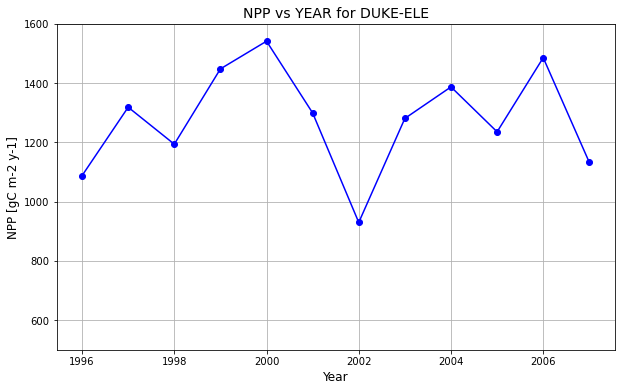

In [12]:
# Create a plot
plt.figure(figsize=(10, 6))
#site = "DUKE"
co2_case = "ELE"
df = dict_obs_ax[site][co2_case]
plt.plot(df['YEAR'], df['NPP'], marker='o', linestyle='-', color='b')

# Adding title and labels
plt.title(f'NPP vs YEAR for {site}-{co2_case}', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.ylim (500, 1600) 
# Show grid and the plot
plt.grid(True)
plt.show()

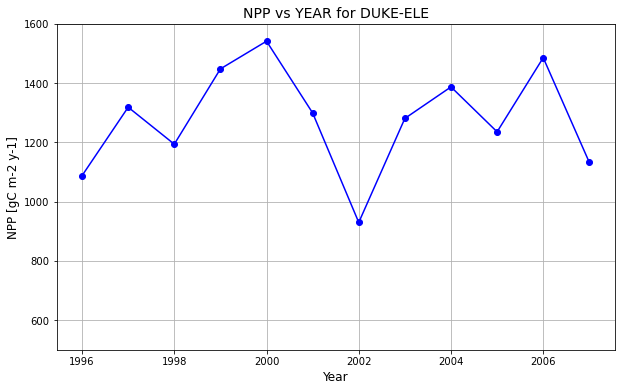

In [13]:
# Create a plot
plt.figure(figsize=(10, 6))

#site = "ORNL"
co2_case = "ELE"
df = dict_obs_ax[site][co2_case]
plt.plot(df['YEAR'], df['NPP'], marker='o', linestyle='-', color='b')

# Adding title and labels
plt.title(f'NPP vs YEAR for {site}-{co2_case}', fontsize=14)
plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.ylim (500, 1600) 
# Show grid and the plot
plt.grid(True)
plt.show()

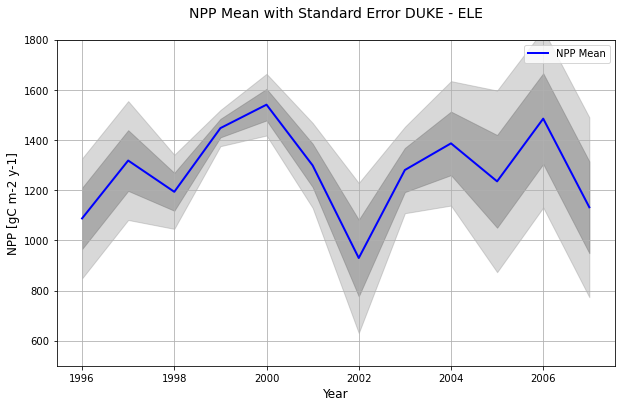

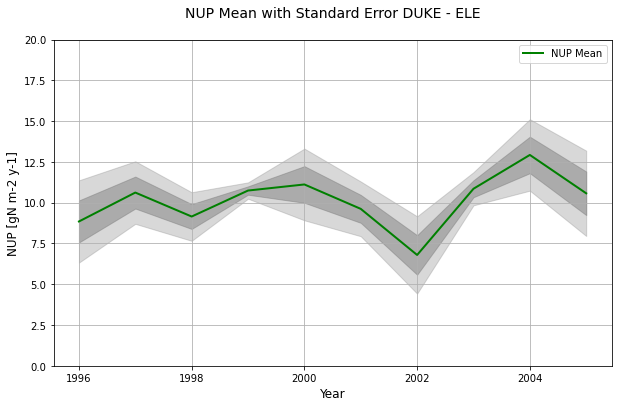

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Sample data from the provided dataframes
# Assuming Mean_DF and Standard_error_DF are pandas DataFrames


#site = "DUKE"
co2_case = "ELE"

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

mean_nup = Mean_DF['NUP']
se_nup = Standard_error_DF['NUP']

# Create the figure and axis
plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NPP Mean', color='blue', lw=2)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
plt.title(f'NPP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (500, 1800) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.show()


plt.figure(figsize=(10, 6))
# Plot NUP with shaded error bars (optional, if you want it on the same plot)
plt.plot(years, mean_nup, label='NUP Mean', color='green', lw=2)
plt.fill_between(years, mean_nup - se_nup, mean_nup + se_nup, color='gray', alpha=0.5)
plt.fill_between(years, mean_nup - se_nup*1.96, mean_nup + se_nup*1.96, color='gray', alpha=0.3)

plt.xlabel('Year', fontsize=12)
plt.ylabel(f'NUP [{NUP_units}]', fontsize=12)
plt.title(f'NUP Mean with Standard Error {site} - {co2_case}\n', fontsize= 14)
plt.legend()
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
plt.show()

In [15]:
Mean_DF

,YEAR,co2,site,NPP,NUP
rownames,,,,,
135,1996.0,ELE,DUKE,1087.418951,8.850000
145,1997.0,ELE,DUKE,1318.136540,10.623333
155,1998.0,ELE,DUKE,1193.488348,9.153333
165,1999.0,ELE,DUKE,1447.362363,10.746667
175,2000.0,ELE,DUKE,1540.805952,11.120000
185,2001.0,ELE,DUKE,1298.723264,9.623333
195,2002.0,ELE,DUKE,929.567928,6.796667
205,2003.0,ELE,DUKE,1280.371220,10.856667
219,2004.0,ELE,DUKE,1386.611473,12.930000


In [16]:
# Read models outputs

# Inputs Models (edit what you want)
- Choose one CO2 case
- Choose RD or ECA


In [76]:

case_id_runs = ["FACE_r241030_Sz_enStoreOvrflw",
]
co2_case = CO2_cases[0] # 0: amb ; 1 :ele

fn = "RD" #RD ECA

fns = ["RD", "ECA"]
fns = ["RD",]

plotly_plots = "y"    
if plotly_plots in ["yes", "y", "YES", "Y"]:
    print ("plotly plots will be plotted" )

plotly plots will be plotted


# Input how many constaints you want to put
Read more [here](https://docs.google.com/presentation/d/1ThmCmvyMYaTbEaALI3XM_UsLA8jH14Dg2tPUYU5xEgM/edit#slide=id.g3022fef1e16_0_67)

In [77]:
path_in = "/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/"
dict_model_sites= {"ORNL" : "US-ORN", "DUKE" : "US-DUK"}
#run_case = "eCO2"
run_CO2_case = {"AMB":"aCO2", "ELE":"eCO2"}
Total_En  = 10

In [78]:
dict_files = {}
for site in sites_o:
    dict_files[site]  ={}
    for case_id_run in case_id_runs:
        case_id = f"{case_id_run}_{fn}"
        for en_idx in np.arange(1,Total_En+1,1):
            dict_files[site][f"{case_id_run}_{fn}_{run_CO2_case[co2_case]}_{en_idx}"] = f"{path_in}{case_id}_processed/{case_id}_{dict_model_sites[site]}_{run_CO2_case[co2_case]}_{'g{:05d}'.format(en_idx)}.nc"

In [79]:
co2_case

'AMB'

In [80]:
 dict_files[site]

{'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00001.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00002.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00003.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00004.nc',
 'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5': '/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g0

In [81]:
# initializing the empty dictionary
ds_full = {}
dict_list_keys = {}
for site in sites_o:
#for site in ["DUKE",]:
    ds_full[site] = {}
    dict_list_keys[site] = []


In [82]:
failed_keys  = ["r240914a_RD_aCO2_en23",
                "r240914a_RD_aCO2_en29",
                "r240914a_ECA_aCO2_en32",
                "r240914a_ECA_aCO2_en36",
                "r240914b_ECA_aCO2_en38",
                "r240914e_ECA_aCO2_en38",
                "r240914c_ECA_aCO2_en29",
                "r240914a_ECA_aCO2_en9",
                "r240914a_ECA_aCO2_en37",
                "r240914a_RD_aCO2_en16",
                "r240914b_RD_aCO2_en13",
                "r240914b_RD_aCO2_en20",
                "r240914c_RD_aCO2_en13",
                "r240914c_RD_aCO2_en20",
                "r240914d_RD_aCO2_en3",
                "r240914c_ECA_eCO2_en29",
                "r240914a_ECA_eCO2_en9",
                "r240914a_ECA_eCO2_en32",
                "r240914a_ECA_eCO2_en36",
                "r240914a_ECA_eCO2_en37",
                "r240914a_RD_eCO2_en16",
                "r240914a_RD_eCO2_en23",
                "r240914b_RD_eCO2_en13",
                "r240914b_RD_eCO2_en20",
                "r240914c_RD_eCO2_en13",
                "r240914c_RD_eCO2_en20",
                "r240914a_RD_eCO2_en29",
                "r240914d_RD_eCO2_en3",
                ]

In [83]:

for site in sites_o:
    for key in dict_files[site].keys():
        print (key, site)
        if key in dict_list_keys[site]:
            continue
        if key not in failed_keys:
            dict_list_keys[site].append(key)
            ds_full[site][f"{key}"]=xr.open_mfdataset(dict_files[site][key])
            print (f"fail: {key}")

FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9
FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_10 DUKE
fail: FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_10


In [84]:
dict_files[site][key]

'/Users/ud4/FATESMDS_analysis/outputs/runs/tests_alp/2024/FACE_r241030_Sz_enStoreOvrflw_RD_processed/FACE_r241030_Sz_enStoreOvrflw_RD_US-DUK_aCO2_g00010.nc'

In [85]:
vars = (#"FATES_GPP",
        #"FATES_NPP",
        #"FATES_EXCESS_RESP",
        #"FATES_L2FR",
        #"FATES_NCOHORTS",
        #"TLAI", 
        #"FATES_AUTORESP",
        "FATES_NPP_Minus_EXCESS_RESP",
        #"FATES_STOREC",
        "NUP",
        #"CUE",
        #"NET_NMIN",
       #"TOTSOMC",
       #"TOTSOMN",
       )
var = vars[0]

In [86]:
params_fname = "vmax_r240615b_RD.csv"
params_fname = "vmax_r240620_RD.csv"
params_fname = "vmax_r240620_ECA.csv"
params_fname = "vmax_r240701_ECA.csv"
params_fname = "vmax_r240701_ECA.xlsx"
params_fname = "vmax_r240703_ECA"
params_fname = "vmax_r240902_RD" 
#params_fname = "vcmax_r240802"# 37 ensembles
#params_fname = "baserate_240830" # 42 ensembles
params_fname = f"vmax_r240913_{fn}" # 37 ensembles
#params_fname = "vmax_r240913_RD" # 37 ensembles
#params_fname = "vmax_r240728_ECA" # 31 ensembles
#params_fname = "baserate_240912" # 21 ensembles

params_fname = f"StoreOvrflw_r241010_{fn}" # 37 ensembles

try:
    #df_vmax_values = pd.read_csv(f"{path_in}{case_id}_processed/{params_fname}.csv")
    #df_vmax_values = pd.read_excel(f"{path_in}{case_id}_processed/{params_fname}.xlsx")
    df_vmax_values = pd.read_excel(f"{path_in}Ensemble_vals/{params_fname}.xlsx")
    print (df_vmax_values)
    #list_legend = df_vmax_values['fates_cnp_vmax_nh4'].values
    list_legend = df_vmax_values['Store_ovrflw'].values
    #list_legend = df_vmax_values['vcmax_vals'].values
    #list_legend = df_vmax_values['non_leaf'].values
except:
    path_tmp = f"{path_in}Ensemble_vals/{params_fname}.xlsx"
    print (".......\nParams file not read | Try again\n.......")
    print (path_tmp)
    pass


# Convert to list of formatted strings
#formatted_list = [f"NH4_{nh4:.01e}_P_{p:.01e}" for nh4, p in zip(df_vmax_values['fates_cnp_vmax_nh4'], df_vmax_values['fates_cnp_vmax_p'])]
#formatted_list = [f"Ovrflw_{so}" for so in zip(df_vmax_values['Store_ovrflw'])]
formatted_list = [f"Ovrflw_{so}" for so in df_vmax_values['Store_ovrflw']]
#formatted_list = [f"Leaf_{nh4:.01e}_NonLeaf_{p:.01e}" for nh4, p in zip(df_vmax_values['leaf'], df_vmax_values['non_leaf'])]
#formatted_list

   RD  Store_ovrflw
0   1           0.0
1   2           0.5
2   3           1.0
3   4           5.0
4   5          10.0
5   6          20.0
6   7          30.0
7   8          50.0
8   9          75.0
9  10         100.0


In [87]:
formatted_list

['Ovrflw_0.0',
 'Ovrflw_0.5',
 'Ovrflw_1.0',
 'Ovrflw_5.0',
 'Ovrflw_10.0',
 'Ovrflw_20.0',
 'Ovrflw_30.0',
 'Ovrflw_50.0',
 'Ovrflw_75.0',
 'Ovrflw_100.0']

In [88]:
def read_nc_data (ds, site, sel_var, keys):
    data = {}
    for key in keys:
        if True:
            print (sel_var,key)
            #case_id = key.split("_")[0]
            if True:#(site in key) and (run_case in key) and (case_id in key):
                #li = int(key.split("_")[-1][2:])-1
            #if True:
                if "FATES_NPP_Minus_EXCESS_RESP" in [sel_var,]:
                    #text_units = ds[site][key]["FATES_NPP"].attrs["units"]
                    #data[f"{formatted_list[li]}"] = ds[site][key]["FATES_NPP"].values.reshape(-1) - ds[site][key]["FATES_EXCESS_RESP"].values.reshape(-1)
                    data[f"{key}"] = (ds[site][key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1)  - ds[site][key]["FATES_EXCESS_RESP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NPP"
                    text_add_var = "_Minus_EXCESS_RESP"
                    var_units = "gC m-2 y-1"
                elif "NUP" in [sel_var,]:
                    #text_units = ds[site][key]["FATES_NH4UPTAKE"].attrs["units"]
                    data[f"{key}"] = (ds[site][key]["FATES_NH4UPTAKE"].resample(time='A').sum().values.reshape(-1)  + ds[site][key]["FATES_NO3UPTAKE"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NH4UPTAKE"
                    text_add_var = "+FATES_NO3UPTAKE"
                    var_units = "gN m-2 y-1"
                elif "FATES_NPP" in [sel_var,]:
                    #text_units = ds[site][key]["FATES_NPP"].attrs["units"]
                    #data[f"{formatted_list[li]}"] = ds[site][key]["FATES_NPP"].values.reshape(-1) - ds[site][key]["FATES_EXCESS_RESP"].values.reshape(-1)
                    data[f"{key}"] = (ds[site][key]["FATES_NPP"].resample(time='A').sum().values.reshape(-1))*1000*24*60*60
                    var = "FATES_NPP"
                    text_add_var = ""
                    var_units = "gC m-2 y-1"
                else:
                    var = sel_var
                    text_add_var=""
                    var_units=ds[site][key][var].units
                    data[f"{key}"] = (ds[site][key][var].resample(time='A').sum().values.reshape(-1))#*1000*24*60*60
                ktmp = key
                #li+=1

    try: 
        if var == "CUE":
            var = "FATES_NPP"  
    except:
        pass

    #time = np.arange(0,len(ds[site][ktmp][var].values.reshape(-1)))
    time = ds[site][ktmp][var].resample(time='A').sum().time

    data['date'] = time
    df = pd.DataFrame(data)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    df.dropna( how="all", inplace=True)
    
    ts_year = []
    for d in df["date"]:
        ts_year.append(pd.to_datetime(d.isoformat()).year)
    df["Year"] = ts_year
    df = df.drop(columns=['date'])
    return df,text_add_var,var_units

In [89]:
dict_df = {}
text_add_var = {}
text_var_units = {}
for site in sites_o:
    print (site)
    dict_df[site] = {}
    text_add_var[site] = {}
    text_var_units[site] = {}
    for var in vars:
        #try:
        dict_df[site][var], text_add_var[site][var], text_var_units[site][var]  = read_nc_data (ds_full, site,var, ds_full[site].keys())
        #except:
        #    pass
    
    
    

DUKE
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9
FATES_NPP_Minus_EXCESS_RESP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_10
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6
NUP FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7
NUP FA

In [90]:
dict_df[site][var]

,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9,FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_10,Year
0,9.613916,10.857774,10.142785,9.797120,9.447345,9.130414,8.875443,7.222403,6.245406,5.530317,1996
1,9.242522,10.741097,10.233055,9.915317,9.591423,9.295636,9.053890,7.421662,6.386397,5.589698,1997
2,8.790007,10.213510,10.072313,9.777812,9.477963,9.201824,8.972899,7.405021,6.373723,5.531412,1998
3,9.202031,10.652901,10.558701,10.423244,10.096719,9.791469,9.536131,7.800096,6.657576,5.681716,1999
4,9.478210,11.033155,10.777281,10.760728,10.758389,10.462036,10.195796,8.347353,7.100109,5.972814,2000
5,9.355659,11.080175,11.142764,10.884697,10.775676,10.775114,10.513118,8.630087,7.372358,6.160700,2001
6,8.542701,9.429846,9.945014,9.960018,9.733923,9.679098,9.779807,8.250832,7.124522,5.981599,2002
7,9.289119,9.547276,10.642447,10.753535,10.783405,10.485512,10.427833,9.029422,7.712595,6.351280,2003
8,9.241628,10.725936,10.024739,10.827307,10.897433,11.037264,10.665545,9.433363,8.072139,6.623723,2004
9,8.954145,10.639334,9.024017,9.466802,10.412745,10.517349,10.655495,9.520712,8.159368,6.706190,2005


### Standard_Error = std/(n^0.5)

In [91]:
dict_df_model_se = {}
for site in sites_o:
    dict_df_model_se[site] = {}
    for var in vars:
        cols_select = dict_df[site][var].columns[:-1]
        print (cols_select)
        dict_df_model_se[site][var] = dict_df[site][var].copy(deep=True)
        dict_df_model_se[site][var]["mean"] = dict_df[site][var][cols_select].mean(axis=1)
        dict_df_model_se[site][var]["std"] = dict_df[site][var][cols_select].std(axis=1)
        dict_df_model_se[site][var]["se"] = dict_df_model_se[site][var]["std"]/(len(cols_select)**0.5)
        dict_df_model_se[site][var] = dict_df_model_se[site][var].drop(columns=cols_select)
        


Index(['FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_10'],
      dtype='object')
Index(['FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_3',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_4',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_5',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_6',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_7',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_8',
       'FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_9',
       'FACE_r241030_Sz_en

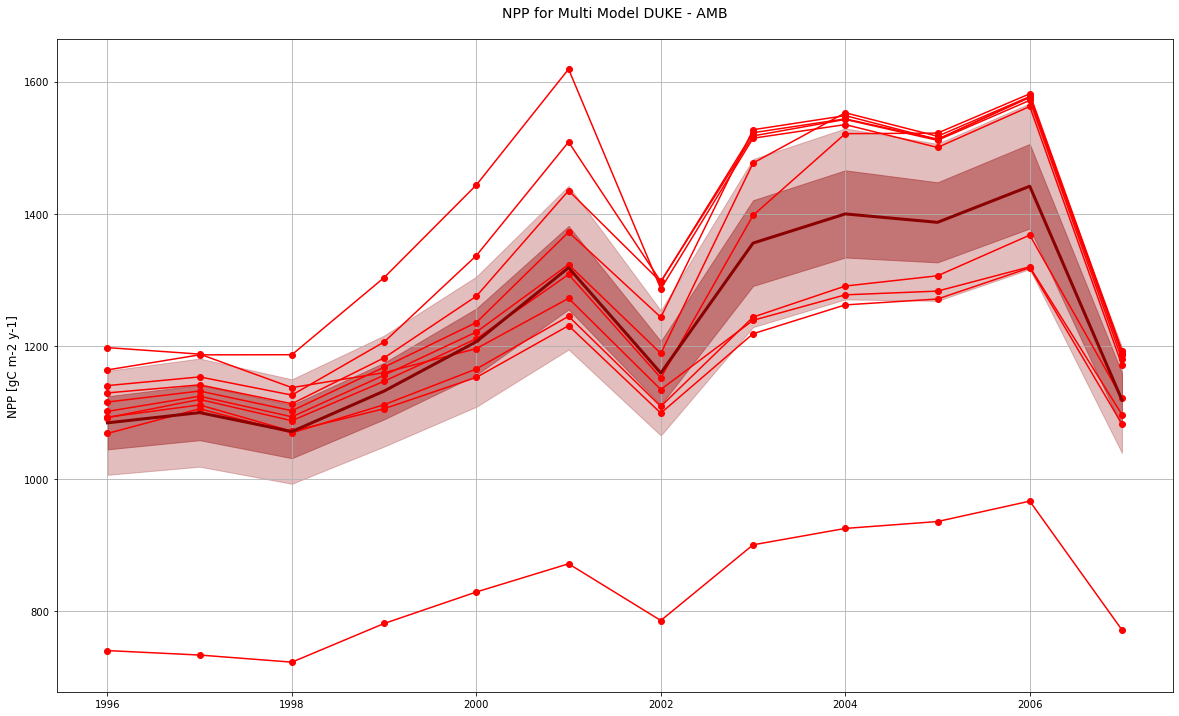

In [92]:
# Set the year as the index
site = "DUKE"

plot_var = "FATES_NPP_Minus_EXCESS_RESP"
#plot_var = "FATES_NPP"
#plot_var = "FATES_STOREC"

df = dict_df[site][f"{plot_var}"]

years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], marker='o', label=column, color="red")
    
mean_model = dict_df_model_se[site][f"{plot_var}"]["mean"]
se_model = dict_df_model_se[site][f"{plot_var}"]["se"]
plt.plot(years, mean_model, label='NPP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)

plt.title(f'NPP for Multi Model {site} - {co2_case}\n', fontsize= 14)
#plt.xlabel('Year')
plt.ylabel(f'NPP [{NPP_units}]', fontsize=12)
#plt.legend()
#plt.ylim (0, 2000) 
plt.grid()
plt.show()


In [93]:
if False:
    # Set the year as the index
    site = "DUKE"
    plot_var = "NUP"
    
    df = dict_df[site][plot_var]
    years = df["Year"]
    #df.set_index('Year', inplace=True)
    
    # Plot the data
    plt.figure(figsize=(20, 12))
    for column in list(df.columns)[:-1]:
        plt.plot(years, df[column], marker='o', label=column)#, color="blue")
    
    mean_model = dict_df_model_se[site]["NUP"]["mean"]
    se_model = dict_df_model_se[site]["NUP"]["se"]
    plt.plot(years, mean_model, label='NUP Mean Model', color='darkred', lw=3)
    plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
    plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)
        
    
    plt.title(f'NUP for Multi Model {site} - {co2_case}\n', fontsize= 14)
    #plt.xlabel('Year')
    plt.ylabel(f'NUP [{NUP_units}]', fontsize=12)
    #plt.legend()
    plt.ylim (0, 20) 
    plt.grid()
    plt.show()

## Mean and SE

AMB RD DUKE


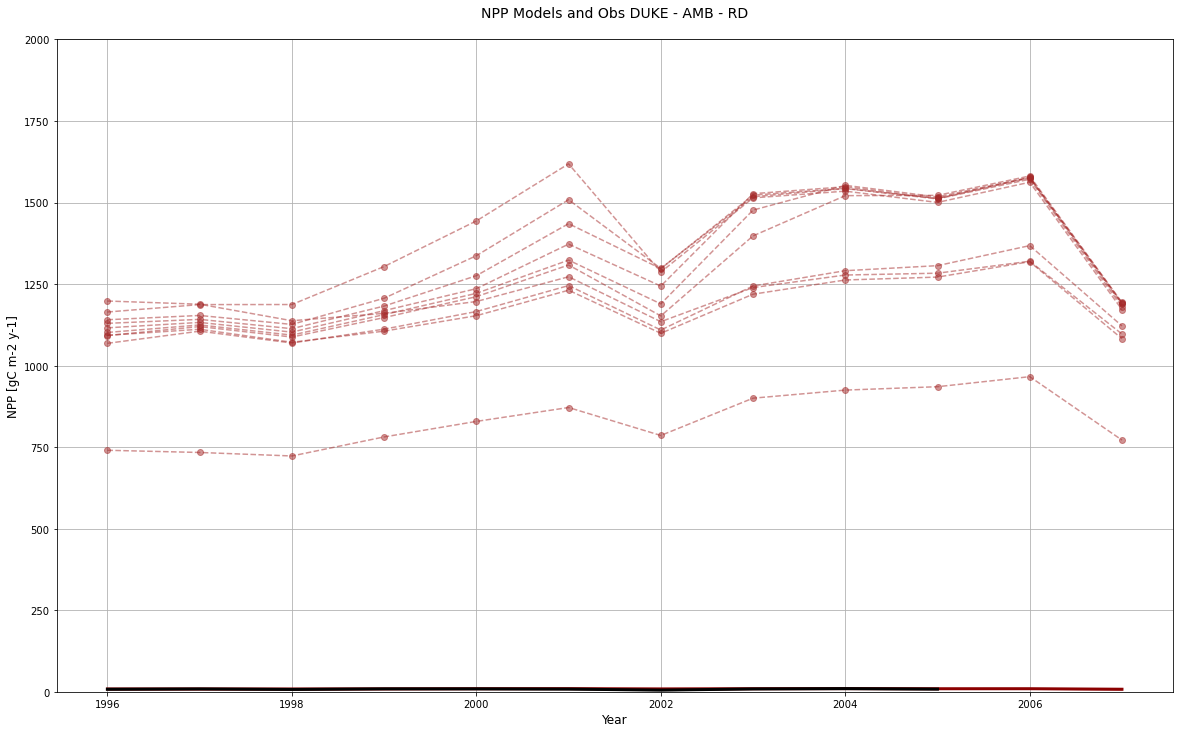

In [94]:
# Set the year as the index

print (co2_case, fn, site)
plot_var = "FATES_NPP_Minus_EXCESS_RESP"; modified_name = "NPP"
#plot_var = "FATES_NPP" ; modified_name = "NPP"
#plot_var = "FATES_STOREC" ; modified_name = "STOREC"

df = dict_df[site][f"{plot_var}"]

years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site][f"{var}"]["mean"]
se_model = dict_df_model_se[site][f"{var}"]["se"]
plt.plot(years, mean_model, label=f'{modified_name} Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.7)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.5)


Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF[f'{var}']
se_npp = Standard_error_DF[f'{var}']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label=f'{modified_name} Mean', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'{modified_name} [{NPP_units}]', fontsize=12)
plt.title(f'{modified_name} Models and Obs {site} - {co2_case} - {fn}\n', fontsize= 14)
#plt.legend()
plt.ylim (0, 2000) 
# Show grid and the plot
plt.grid(True)
# Display the plot
#plt.show()


AMB RD


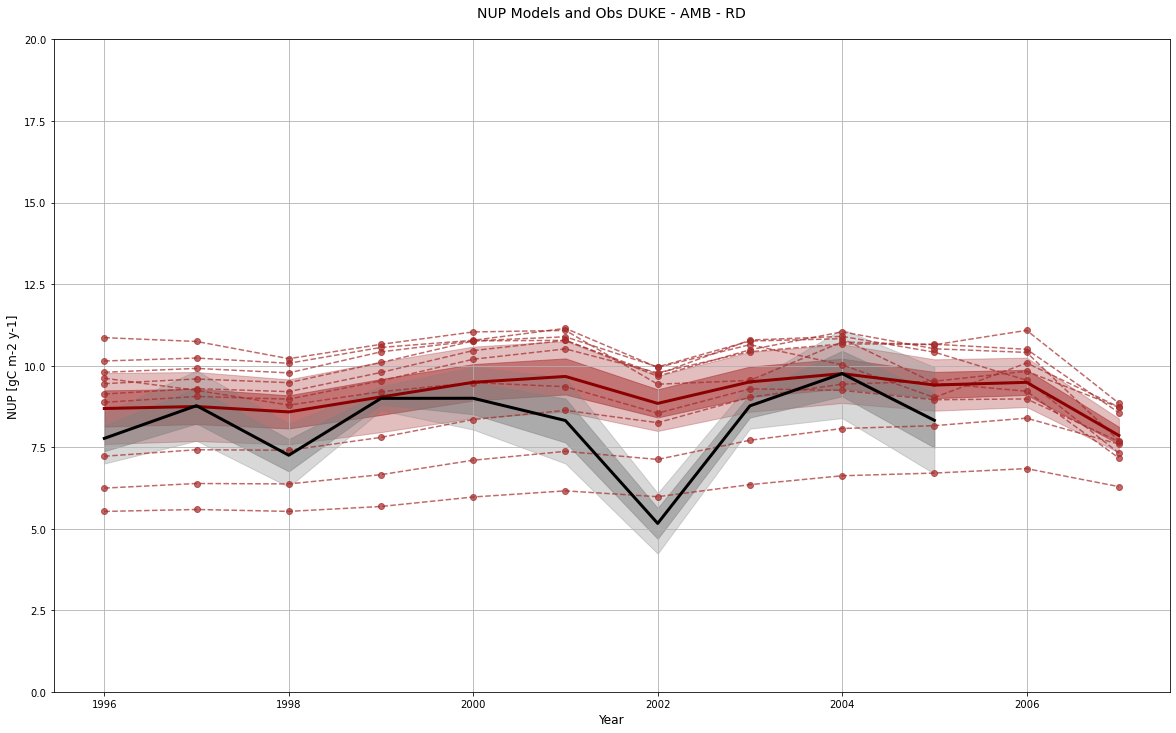

In [95]:
# Set the year as the index
site = "DUKE"
print (co2_case, fn)

df = dict_df[site]["NUP"]
years = df["Year"]
#df.set_index('Year', inplace=True)

# Plot the data
plt.figure(figsize=(20, 12))
for column in list(df.columns)[:-1]:
    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.7)
    
    
mean_model = dict_df_model_se[site]["NUP"]["mean"]
se_model = dict_df_model_se[site]["NUP"]["se"]
plt.plot(years, mean_model, label='NUP Mean Model', color='darkred', lw=3)
plt.fill_between(years, mean_model - se_model, mean_model + se_model, color='brown', alpha=0.5)
plt.fill_between(years, mean_model - se_model*1.96, mean_model + se_model*1.96, color='brown', alpha=0.3)


Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='NUP Mean', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, color='gray', alpha=0.3)

# Add labels and title
plt.xlabel('Year',fontsize=12 )
plt.ylabel(f'NUP [{NPP_units}]', fontsize=12)
plt.title(f'NUP Models and Obs {site} - {co2_case} - {fn}\n', fontsize= 14)
#plt.legend()
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.show()


In [96]:
print (site, co2_case, fn, var)

DUKE AMB RD NUP


In [97]:
print (dict_df.keys())
for key in dict_df.keys():
    print (dict_df[key].keys())


dict_keys(['DUKE'])
dict_keys(['FATES_NPP_Minus_EXCESS_RESP', 'NUP'])


In [98]:
vars

('FATES_NPP_Minus_EXCESS_RESP', 'NUP')

In [99]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Plotly Plots

In [ ]:
# Build the following with 
## - sites_o
## - CO2_cases
## - RD ECA
## - checks 3#
## - vars : FATES_NPP_Minus_EXCESS_RESP



# Run the following cell only once, then turn to raw

### We have in the previous run 

In [100]:
print (site, co2_case, fn, var)

DUKE AMB RD NUP


In [101]:
# run this one by one
for site in sites_o:
    for var in vars:
        dict_plotly[site][co2_case][fn][var] = dict_df[site][var]

In [102]:
dict_plotly

{'DUKE': {'AMB': {'RD': {'FATES_NPP_Minus_EXCESS_RESP':     FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_1  \
    0                                740.507263   
    1                                733.768799   
    2                                723.037354   
    3                                781.421143   
    4                                829.013245   
    5                                871.603516   
    6                                785.922241   
    7                                900.242249   
    8                                925.002808   
    9                                935.406982   
    10                               966.186462   
    11                               771.724487   
    
        FACE_r241030_Sz_enStoreOvrflw_RD_aCO2_2  \
    0                               1164.414185   
    1                               1187.173828   
    2                               1187.366333   
    3                               1303.853638   
    4                    

In [103]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [104]:
# After you have the cases run for reponse

In [105]:
# Response:
dict_plotly_response = {}
for site in sites_o:
    dict_plotly_response[site] = {}
    for fn in fns:
        dict_plotly_response[site][fn] = {}

In [106]:
tmp_cols = list(dict_plotly[site]["AMB"][fn][var].columns)
# Replace "aCO2" with "response"
tmp_cols = [item.replace('aCO2', 'response') for item in tmp_cols]

for site in sites_o:
    for fn in fns:
        for var in vars:
            tmp_A = dict_plotly[site]["ELE"][fn][var].copy(deep = True)
            tmp_B = dict_plotly[site]["AMB"][fn][var].copy(deep = True)
            # Replacing the column names of tmp_A with tmp_cols
            tmp_A.columns = tmp_cols
            tmp_B.columns = tmp_cols
            dict_plotly_response[site][fn][var] = tmp_A - tmp_B
            dict_plotly_response[site][fn][var]["Year"] = tmp_A["Year"]
            del tmp_A, tmp_B

## Plotly Plots Ensembles

In [107]:
path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
co2_case = CO2_cases[0]
print (co2_case)

AMB


In [108]:
fns

['RD']

In [109]:
for site in sites_o:
    for var in vars:
        for fn in fns:
            # model en
            df_tmp = dict_plotly[site][co2_case][fn][var].copy(deep=True)
            df_save_tmp_mods = pd.DataFrame(df_tmp.mean())
            #obs
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            elif var == "FATES_NPP":
                var_tmp = "NPP"
            else:
                var_tmp = var
            mean_ar = dict_obs_ax[site][co2_case][var_tmp].values
            lower_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values
            upper_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values
            df_save_tmp_obs = pd.DataFrame(
                {
                    'Mean': mean_ar,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                },
                index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
            )
            
            
            
            df_save_tmp_mods.to_csv(f"{path_html_save}/mods_summary_{var}_{site}_{fn}_{co2_case}_{case_id}.csv")
            df_save_tmp_obs.to_csv(f"{path_html_save}/obs_summary_{var}_{site}_{fn}_{co2_case}_{case_id}.csv")

DUKE
FATES_NPP_Minus_EXCESS_RESP
FATES_NPP_Minus_EXCESS_RESP_DUKE_RD_AMB_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


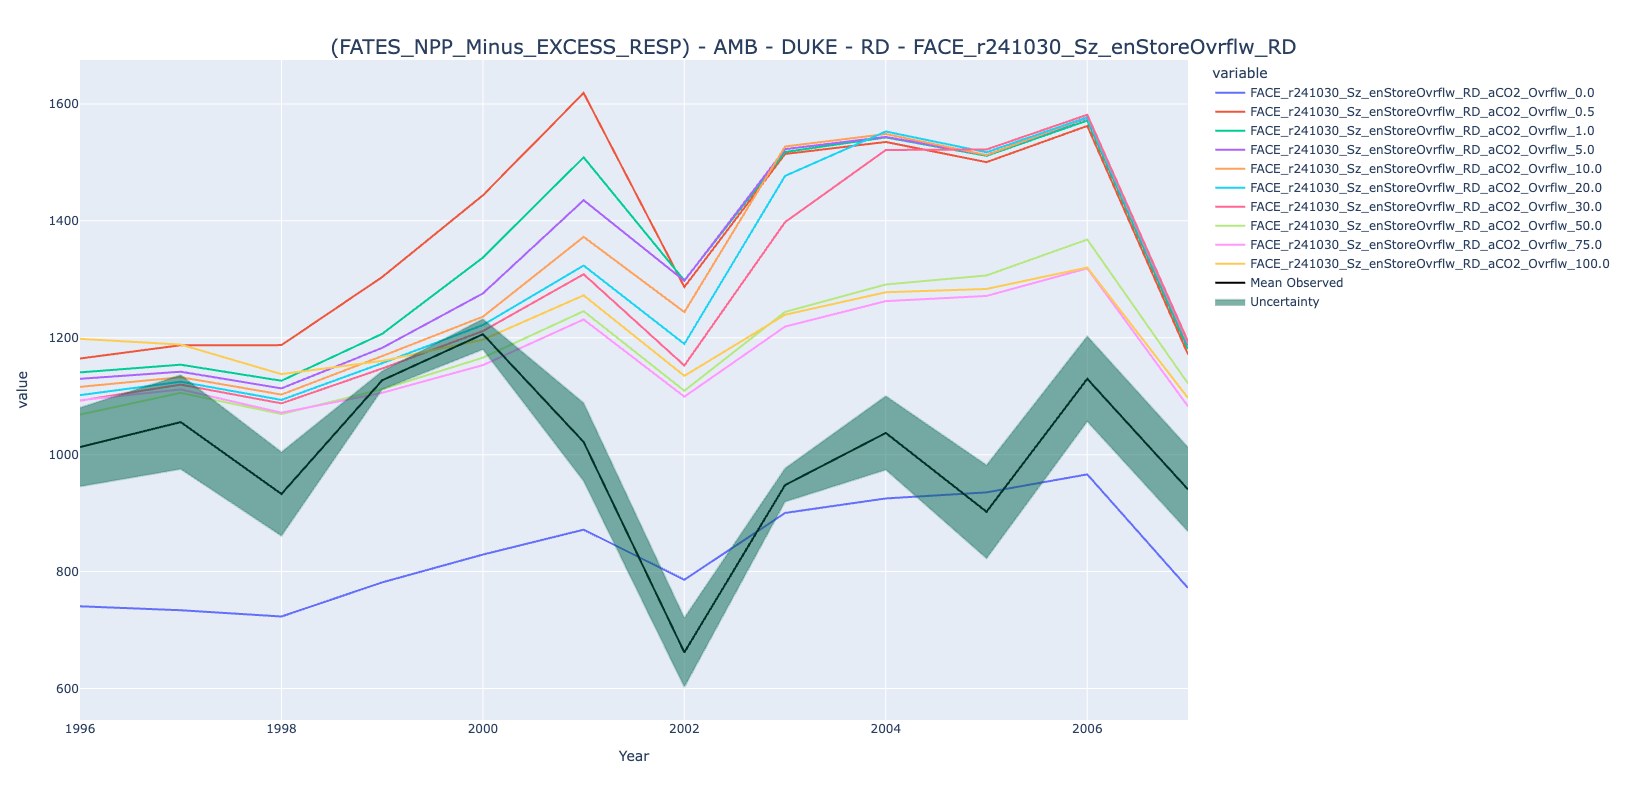

NUP
NUP_DUKE_RD_AMB_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


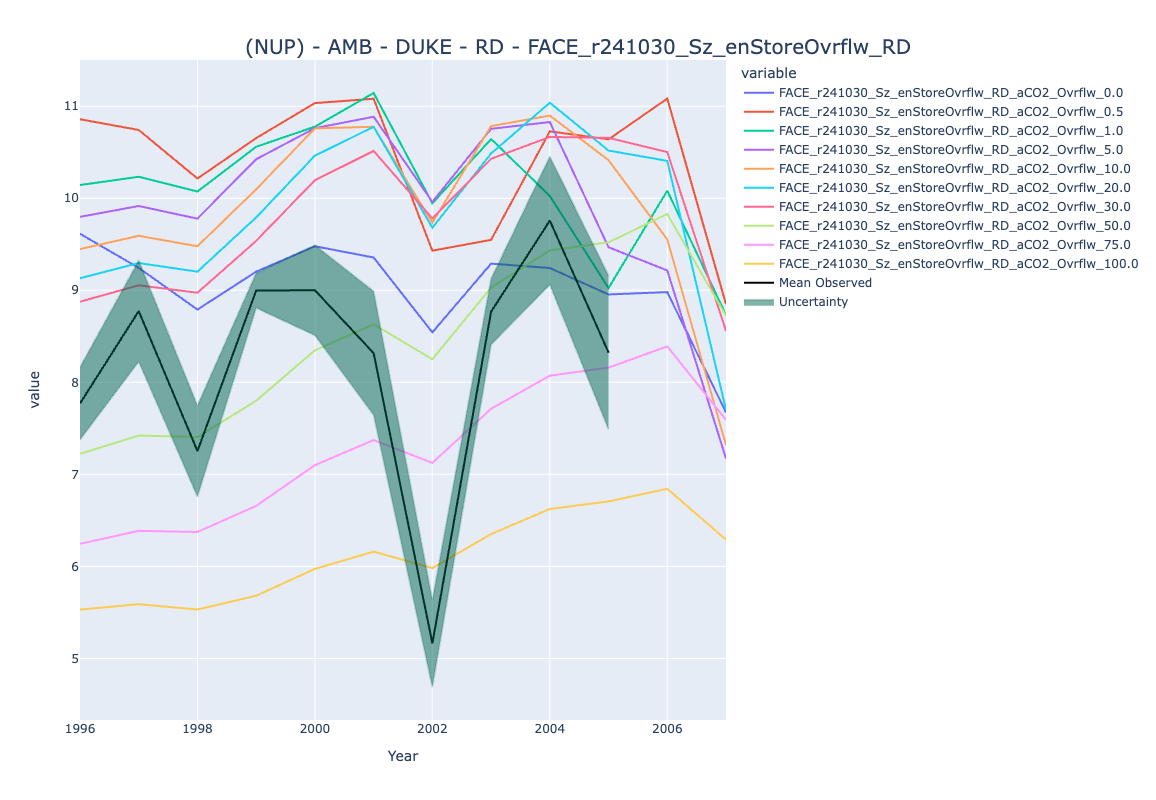

In [110]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px




if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            for fn in fns:
                df_tmp = dict_plotly[site][co2_case][fn][var].copy(deep=True)
                # Replace the last number after "_" with the corresponding value from new_values
                new_columns = [col.rsplit('_', 1)[0] + f'_{formatted_list[i]}' for i, col in enumerate(df_tmp.columns[:-1])]
                new_columns.append('Year')
                df_tmp.columns = new_columns
                
                #df_tmp = dict_df[site][var].copy(deep=True)
                if var == "FATES_NPP_Minus_EXCESS_RESP":
                    var_tmp = "NPP"
                elif var == "FATES_NPP":
                    var_tmp = "NPP"
                else:
                    var_tmp = var

                fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
                  hover_data={"Year": "%Y"},)
                fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][co2_case][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
                # Add a filled polygon (e.g., for uncertainty)
                # Example: creating upper and lower bounds
                lower_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values
                upper_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values

                # Fill between the lower and upper bounds
                fig.add_traces([
                    go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
                # Update layout with a custom title
                fig.update_layout(
                title={
                    'text': f" ({var}) - {co2_case} - {site} - {fn} - {case_id} ",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

                # Save the plot as an HTML file
                path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
                #fig.write_html(f"{path_html_save}/{var}_{site}_{fn}_{co2_case}_minC{min_checks}_line_plot.html")

                print (f"{var}_{site}_{fn}_{co2_case}_{case_id}_line_plot.html")

                # Show the plot
                fig.show()

### Plotly Response Ensembles

In [123]:

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']


#### Save excel summary

In [124]:
for site in sites_o:
    for var in vars:
        for fn in fns:
            # model en
            df_tmp = dict_plotly_response[site][fn][var].copy(deep=True)
            df_save_tmp_mods = pd.DataFrame(df_tmp.mean())
            #obs
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            else:
                var_tmp = var
            mean_ar = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values
            SE = ((dict_obs_ase[site][CO2_cases[0]][var_tmp].values)**2 + (dict_obs_ase[site][CO2_cases[1]][var_tmp].values)**2)**0.5
            lower_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values - SE
            upper_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values + SE
            df_save_tmp_obs = pd.DataFrame(
                {
                    'Mean': mean_ar,
                    'Lower Bound': lower_bound,
                    'Upper Bound': upper_bound
                },
                index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
            )
            
            
            
            df_save_tmp_mods.to_csv(f"{path_html_save}/mods_summary_Response_{var}_{site}_{fn}_{case_id}.csv")
            #df_save_tmp_obs.to_csv(f"{path_html_save}/obs_summary_Response_{var}_{site}_{fn}.csv")

In [125]:
pd.DataFrame(
    {
        'Mean': mean_ar,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound
    },
    index=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)
)


,Mean,Lower Bound,Upper Bound
1996,1.080000,-0.266081,2.426081
1997,1.850000,0.727820,2.972180
1998,1.900000,0.993235,2.806765
1999,1.750000,1.431793,2.068207
2000,2.120000,0.895813,3.344187
2001,1.306667,0.218187,2.395147
2002,1.633333,0.334877,2.931790
2003,2.090000,1.459903,2.720097
2004,3.173333,1.856527,4.490139
2005,2.253333,0.679149,3.827517


In [126]:
! open /Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots/.

In [127]:
np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int)

array([1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006,
       2007])

In [128]:
dict_plotly_response[site][fn][var]

,FACE_r241030_Sz_enStoreOvrflw_RD_response_1,FACE_r241030_Sz_enStoreOvrflw_RD_response_2,FACE_r241030_Sz_enStoreOvrflw_RD_response_3,FACE_r241030_Sz_enStoreOvrflw_RD_response_4,FACE_r241030_Sz_enStoreOvrflw_RD_response_5,FACE_r241030_Sz_enStoreOvrflw_RD_response_6,FACE_r241030_Sz_enStoreOvrflw_RD_response_7,FACE_r241030_Sz_enStoreOvrflw_RD_response_8,FACE_r241030_Sz_enStoreOvrflw_RD_response_9,FACE_r241030_Sz_enStoreOvrflw_RD_response_10,Year
0,0.007862,0.010402,0.009386,0.008960,0.008537,0.008171,0.007860,0.006011,0.004958,0.004208,1996
1,0.110438,0.217022,0.113432,0.110753,0.106974,0.103867,0.100762,0.078008,0.061530,0.046378,1997
2,0.163218,0.460893,0.083660,0.105636,0.118490,0.127573,0.132657,0.127609,0.103039,0.048461,1998
3,0.106296,0.282535,-0.014702,-0.148023,-0.098744,-0.056228,-0.027177,0.065662,0.064298,-0.031530,1999
4,0.065123,-0.150761,0.132415,-0.116321,-0.382610,-0.338622,-0.286743,-0.059971,-0.017686,-0.141233,2000
5,0.078106,-0.260551,-0.275846,-0.137362,-0.285815,-0.539685,-0.523317,-0.201632,-0.114467,-0.229920,2001
6,0.095504,0.318118,-0.175547,-0.094542,0.029290,-0.142218,-0.438273,-0.281991,-0.176194,-0.259649,2002
7,0.011827,0.662845,-0.369327,-0.502485,-0.420830,-0.178371,-0.336156,-0.546092,-0.364216,-0.385278,2003
8,0.010382,-0.399182,0.535123,-0.409749,-0.524326,-0.631169,-0.296027,-0.677421,-0.470295,-0.447308,2004
9,0.038073,-0.692801,1.173295,0.833575,-0.328435,-0.436631,-0.516266,-0.712710,-0.509227,-0.453105,2005


In [129]:
formatted_list

['Ovrflw_0.0',
 'Ovrflw_0.5',
 'Ovrflw_1.0',
 'Ovrflw_5.0',
 'Ovrflw_10.0',
 'Ovrflw_20.0',
 'Ovrflw_30.0',
 'Ovrflw_50.0',
 'Ovrflw_75.0',
 'Ovrflw_100.0']

DUKE
FATES_NPP_Minus_EXCESS_RESP
Response_FATES_NPP_Minus_EXCESS_RESP_DUKE_RD_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


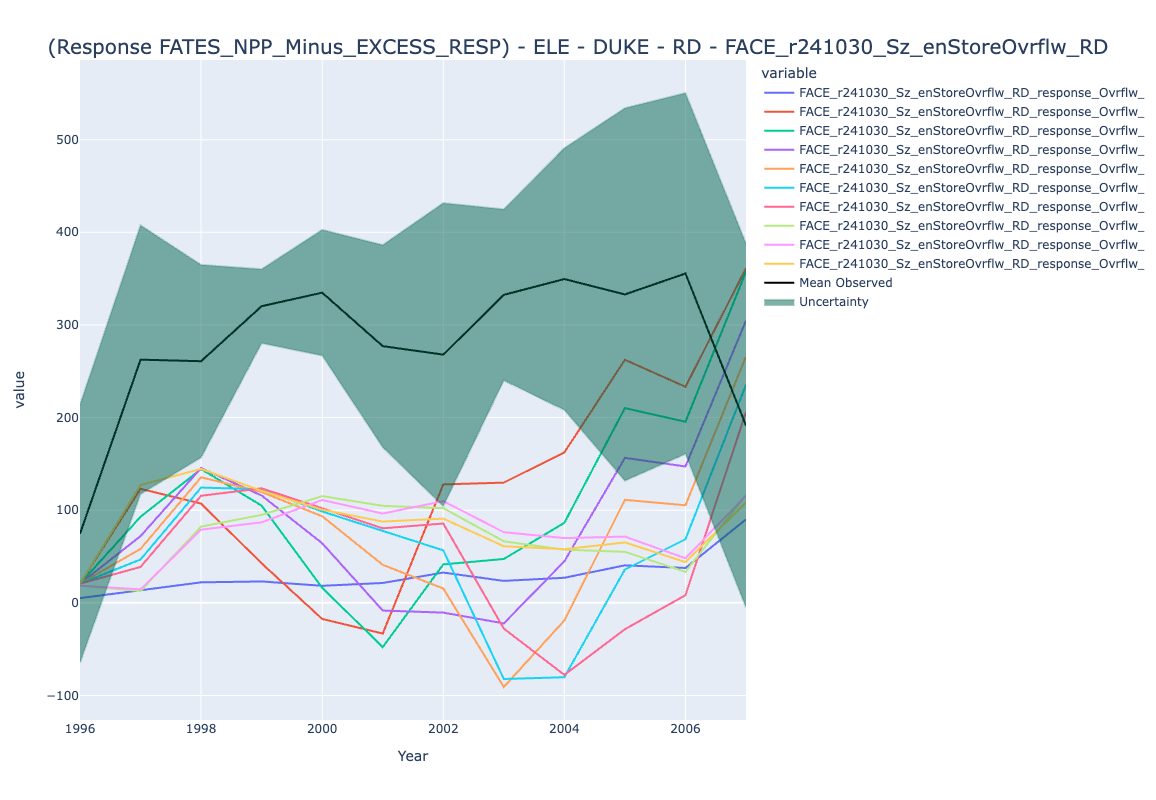

NUP
Response_NUP_DUKE_RD_FACE_r241030_Sz_enStoreOvrflw_RD_line_plot.html


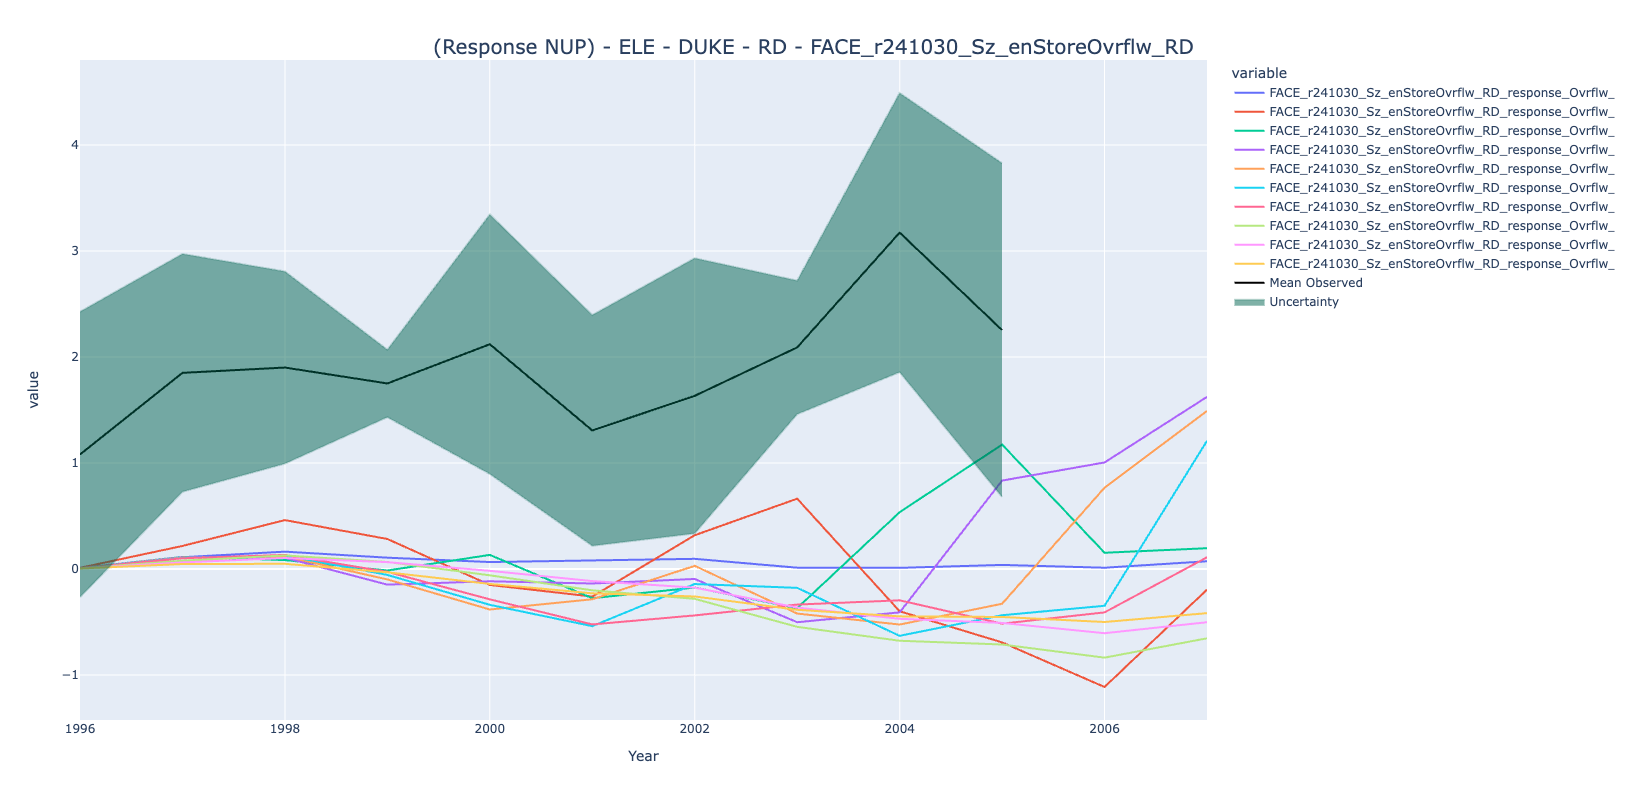

In [130]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            for fn in fns:
                df_tmp = dict_plotly_response[site][fn][var].copy(deep=True)
                # Replace the last number after "_" with the corresponding value from new_values
                new_columns = [col.rsplit('_', 1)[0] + f'_{formatted_list[i]}' for i, col in enumerate(df_tmp.columns[:-1])]
                new_columns.append('Year')
                df_tmp.columns = new_columns
                if var == "FATES_NPP_Minus_EXCESS_RESP":
                    var_tmp = "NPP"
                elif var == "FATES_NPP":
                    var_tmp = "NPP"
                else:
                    var_tmp = var

                fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
                  hover_data={"Year": "%Y"},)
                fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
                # Add a filled polygon (e.g., for uncertainty)
                # Example: creating upper and lower bounds
                SE = ((dict_obs_ase[site][CO2_cases[0]][var_tmp].values)**2 + (dict_obs_ase[site][CO2_cases[1]][var_tmp].values)**2)**0.5
                lower_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values - SE
                upper_bound = dict_obs_ax[site][CO2_cases[1]][var_tmp].values - dict_obs_ax[site][CO2_cases[0]][var_tmp].values + SE

                # Fill between the lower and upper bounds
                fig.add_traces([
                    go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
                # Update layout with a custom title
                fig.update_layout(
                title={
                    'text': f" (Response {var}) - {co2_case} - {site} - {fn} - {case_id} ",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

                # Save the plot as an HTML file
                path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
                fig.write_html(f"{path_html_save}/Response_{var}_{site}_{fn}_{case_id}_line_plot.html")

                print (f"Response_{var}_{site}_{fn}_{case_id}_line_plot.html")

                # Show the plot
                fig.show()

In [131]:
path_html_save

'/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots'

In [132]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
if plotly_plots in ["yes", "y", "YES", "Y"]:
    for site in sites_o:
        print(site)
        for var in vars:
            print (var)
            df_tmp = dict_df[site][var].copy(deep=True)
            if var == "FATES_NPP_Minus_EXCESS_RESP":
                var_tmp = "NPP"
            elif var == "FATES_NPP":
                var_tmp = "NPP"
            else:
                var_tmp = var

            fig = px.line(df_tmp[:], x="Year", y=df_tmp.columns,
              hover_data={"Year": "%Y"},
              title=f" ({var}) - {site} \n")
            fig.add_scatter(x=np.array(dict_obs_ax[site][co2_case]["YEAR"].values, dtype=int), 
                            y=dict_obs_ax[site][co2_case][var_tmp].values, 
                            mode='lines', 
                            name='Mean Observed', line=dict(color='black', width=2))
            
            # Add a filled polygon (e.g., for uncertainty)
            # Example: creating upper and lower bounds
            lower_bound = dict_obs_ax[site][co2_case][var_tmp].values + dict_obs_ase[site][co2_case][var_tmp].values
            upper_bound = dict_obs_ax[site][co2_case][var_tmp].values - dict_obs_ase[site][co2_case][var_tmp].values

            # Fill between the lower and upper bounds
            fig.add_traces([
                go.Scatter(
                    x=df_tmp['Year'], y=upper_bound, 
                    fill=None, mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    showlegend=False
                ),
                go.Scatter(
                    x=df_tmp['Year'], y=lower_bound, 
                    fill='tonexty', mode='lines', line=dict(color='rgba(0,100,80,0.2)'), 
                    name='Uncertainty'
                )
            ])
            
            
            # Update layout with a custom title
            fig.update_layout(
                title={
                    'text': f" ({var}) - {co2_case} - {site} - Min Check {min_checks}",
                    'y': 0.95,  # Position title slightly above the plot
                    'x': 0.5,  # Center the title horizontally
                    'xanchor': 'center',
                    'yanchor': 'top'
                },
                title_font=dict(size=20),  # Adjust the font size of the title
                width=1200, height=800  # Adjust width and height as needed
            )

            # Save the plot as an HTML file
            path_html_save = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/HTML_plots"
            #fig.write_html(f"{path_html_save}/{var}_{site}_{co2_case}_line_plot.html")

            print (f"{var}_{site}_{co2_case}_line_plot.html")

            # Show the plot
            fig.show()

DUKE
FATES_NPP_Minus_EXCESS_RESP


NameError: name 'min_checks' is not defined

In [133]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

## Plots Mean and std (models); Mean and SE (obs)

In [134]:
# Set the year as the index
site = "ORNL"
print (co2_case, fn)

# Plot the data
plt.figure(figsize=(20, 12))


# OBS

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
se_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["se"]
std_model = dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"]["std"]
plt.plot(years, mean_model, label=f'Model μ {fn}', color='blue', lw=3)
plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color='blue', alpha=0.4)
plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color='blue', alpha=0.2)


# Add labels and title
plt.xlabel('Year',fontsize=14 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=14)
plt.title(f'NPP Models and Obs {site} - {co2_case} - {fn} {min_checks}\n', fontsize= 16)
plt.legend(fontsize=14, loc="lower right")
plt.ylim (0, 2000) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NPP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()


ELE RD


KeyError: 'ORNL'

<Figure size 1440x864 with 0 Axes>

In [135]:
# Set the year as the index
site = "ORNL"
print (co2_case, fn)

# Plot the data
plt.figure(figsize=(20, 12))

# OBS

Mean_DF = dict_obs_ax[site][co2_case]
Standard_error_DF = dict_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_df[site]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    
    
mean_model = dict_df_model_se[site]["NUP"]["mean"]
se_model = dict_df_model_se[site]["NUP"]["se"]
std_model = dict_df_model_se[site]["NUP"]["std"]
plt.plot(years, mean_model, label=f'Model μ {fn}', color='blue', lw=3)
plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color='blue', alpha=0.4)
plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color='blue', alpha=0.2)


# Add labels and title
plt.xlabel('Year',fontsize=14 )
plt.ylabel(f'NUP [{NUP_units}]', fontsize=14)
plt.title(f'NUP Models and Obs {site} - {co2_case} - {fn} {min_checks}\n', fontsize= 16)
plt.legend(fontsize=14, loc="upper right")
plt.ylim (0, 20) 
# Show grid and the plot
plt.grid(True)
# Display the plot
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NUP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.png",bbox_inches='tight')
plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/NUP_Modex_{site}_{co2_case}_{fn}_Checks_{min_checks}.pdf",bbox_inches='tight')
plt.show()


ELE RD


KeyError: 'ORNL'

<Figure size 1440x864 with 0 Axes>

# Saving the data for combined plots


In [136]:
# Set the year as the index
site = "DUKE"
print (co2_case, fn)

save_dir = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots"
# OBS

dict_obs_ax[site][co2_case].to_csv(f"{save_dir}/obs_ax_{site}_{co2_case}.csv")
dict_obs_ase[site][co2_case].to_csv(f"{save_dir}/obs_ase_{site}_{co2_case}.csv")
for site in sites_o:
    dict_df_model_se[site]["FATES_NPP_Minus_EXCESS_RESP"].to_csv(f"{save_dir}/Model_NPP_{fn}_{site}_{co2_case}_check_{min_checks}.csv")
    dict_df_model_se[site]["NUP"].to_csv(f"{save_dir}/Model_NUP_{fn}_{site}_{co2_case}_check_{min_checks}.csv")
#se_model = dict_df_model_se[site]["NUP"]["se"]
#std_model = dict_df_model_se[site]["NUP"]["std"]


ELE RD


NameError: name 'min_checks' is not defined

In [137]:
dict_obs_ase[site][co2_case]

,YEAR,co2,site,NPP,NUP
rownames,,,,,
135,1996.0,ELE,DUKE,121.959042,1.287258
145,1997.0,ELE,DUKE,120.861949,0.978678
155,1998.0,ELE,DUKE,75.386064,0.759832
165,1999.0,ELE,DUKE,36.766733,0.255430
175,2000.0,ELE,DUKE,62.769683,1.121710
185,2001.0,ELE,DUKE,86.415692,0.856141
195,2002.0,ELE,DUKE,152.615302,1.209095
205,2003.0,ELE,DUKE,87.884493,0.519145
219,2004.0,ELE,DUKE,126.539905,1.117721


In [138]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Can be run independently

## Read processed data and plot

In [139]:
import matplotlib.pyplot as plt
import pandas as pd
import pyreadr
import xarray as xr
import numpy as np


In [140]:
save_dir = "/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots"
#sites_o= ("ORNL", "DUKE" )

CO2_cases  = ("AMB", "ELE" )
# Units

NPP_units = "gC m$^{-2}$ y$^{-1}$"
NUP_units = "gN m$^{-2}$ y$^{-1}$"

In [141]:
# REading obs data
## site, CO2
dict_plot_data_obs_ax = {}
dict_plot_data_obs_ase = {}
for site in sites_o:
    dict_plot_data_obs_ax[site]={}
    dict_plot_data_obs_ase[site]={}
    for co2_case in CO2_cases:
        dict_plot_data_obs_ax[site][co2_case]= pd.read_csv(f"{save_dir}/obs_ax_{site}_{co2_case}.csv", index_col=0)
        dict_plot_data_obs_ase[site][co2_case]= pd.read_csv(f"{save_dir}/obs_ase_{site}_{co2_case}.csv", index_col=0)
        
# reading model data
## site, CO2, var, fN, checks

dict_plot_data_mod = {}
for site in sites_o:
    dict_plot_data_mod[site] = {}
    for co2_case in CO2_cases:
        dict_plot_data_mod[site][co2_case] = {}
        for fn in fns:
            dict_plot_data_mod[site][co2_case][fn] = {}
            if True:
                if True:
                    # vars
                    dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"] = pd.read_csv(
                        f"{save_dir}/Model_NPP_{fn}_{site}_{co2_case}_singlerun.csv", index_col=0)
                    dict_plot_data_mod[site][co2_case][fn]["NUP"] = pd.read_csv(
                        f"{save_dir}/Model_NUP_{fn}_{site}_{co2_case}_singlerun.csv", index_col=0)
                    
                
        
    



## Select what to plot for NPP (final)

In [142]:
site = "DUKE"
co2_case = CO2_cases[1] # 0: amb ; 1 :ele
print (site, "\t", co2_case, "\t",fns , "\t" ) 

DUKE 	 ELE 	 ['RD'] 	


In [143]:
dict_plot_data_mod[site][co2_case][fn]

{'FATES_NPP_Minus_EXCESS_RESP':     Year       mean  std  se
 0   1996  1702.1528  NaN NaN
 1   1997  1994.4225  NaN NaN
 2   1998  1936.6783  NaN NaN
 3   1999  1859.9861  NaN NaN
 4   2000  1602.0487  NaN NaN
 5   2001  1664.8245  NaN NaN
 6   2002  1442.7064  NaN NaN
 7   2003  1554.0039  NaN NaN
 8   2004  1537.1990  NaN NaN
 9   2005  1534.6781  NaN NaN
 10  2006  1561.2886  NaN NaN
 11  2007  1343.8310  NaN NaN
 12  2008  1487.5210  NaN NaN
 13  2009  1466.6705  NaN NaN
 14  2010  1410.1147  NaN NaN
 15  2011  1462.6584  NaN NaN
 16  2012  1483.7377  NaN NaN,
 'NUP':     Year      mean  std  se
 0   1996  6.791901  NaN NaN
 1   1997  6.775822  NaN NaN
 2   1998  6.628906  NaN NaN
 3   1999  6.676957  NaN NaN
 4   2000  6.667891  NaN NaN
 5   2001  6.594791  NaN NaN
 6   2002  6.288742  NaN NaN
 7   2003  6.437877  NaN NaN
 8   2004  6.453083  NaN NaN
 9   2005  6.431269  NaN NaN
 10  2006  6.487363  NaN NaN
 11  2007  6.059193  NaN NaN
 12  2008  6.310408  NaN NaN
 13  2009  6.31

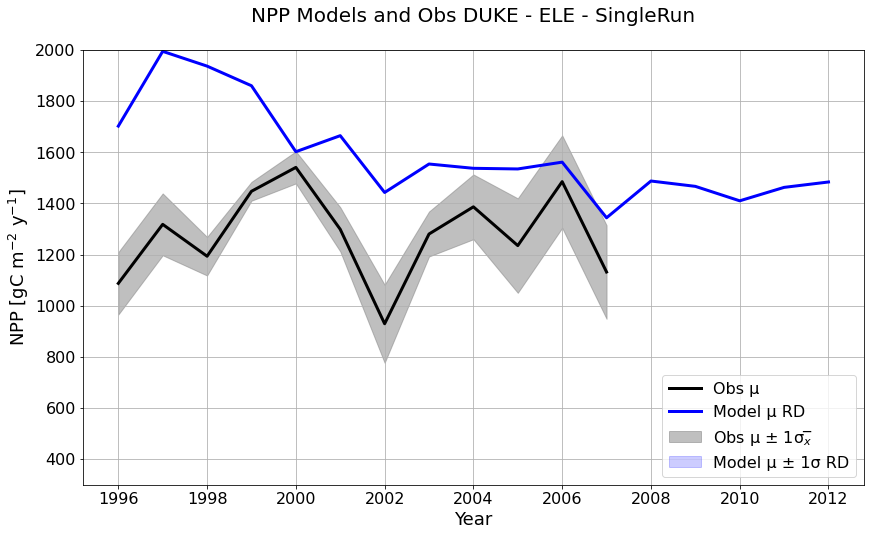

In [144]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF = dict_plot_data_obs_ax[site][co2_case]
Standard_error_DF = dict_plot_data_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]

for fn in fns:
    mean_model = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
    std_model  = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["std"]
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=18)
plt.title(f'NPP Models and Obs {site} - {co2_case} - SingleRun\n', fontsize= 20)
if site == "DUKE":
    plt.legend(fontsize=16, loc="lower right")
if site == "ORNL":
    plt.legend(fontsize=16, loc="upper right")
plt.ylim (300, 2000) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show grid and the plot
plt.grid(True)
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NPP_Modex_{site}_{co2_case}_SingleRun.png",bbox_inches='tight')
plt.show()


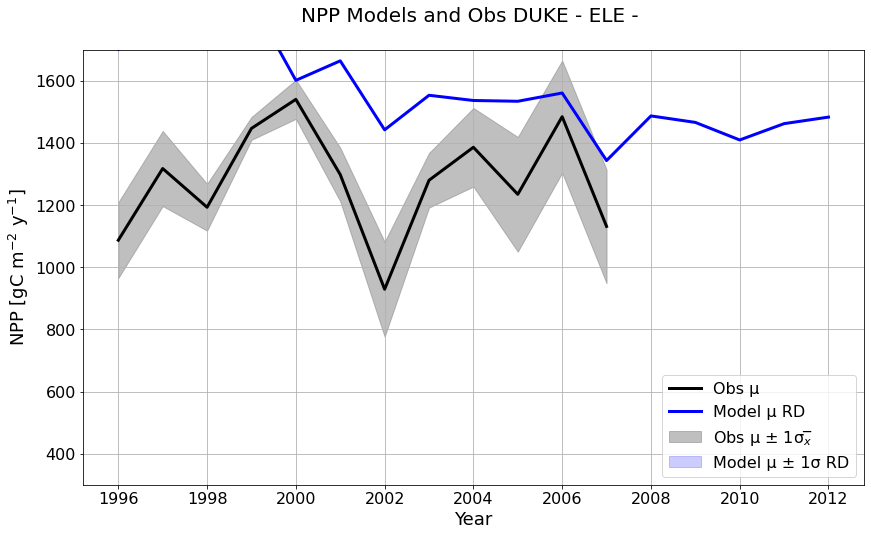

In [145]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF = dict_plot_data_obs_ax[site][co2_case]
Standard_error_DF = dict_plot_data_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]
years = df["Year"]

for fn in fns:
    mean_model = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["mean"]
    std_model  = dict_plot_data_mod[site][co2_case][fn]["FATES_NPP_Minus_EXCESS_RESP"]["std"]
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=18)
plt.title(f'NPP Models and Obs {site} - {co2_case} - \n', fontsize= 20)
if site == "DUKE":
    plt.legend(fontsize=16, loc="lower right")
if site == "ORNL":
    plt.legend(fontsize=16, loc="upper right")
plt.ylim (300, 1700) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show grid and the plot
plt.grid(True)
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NPP_Modex_{site}_{co2_case}_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()


## plot for NUP (final)

NameError: name 'min_checks' is not defined

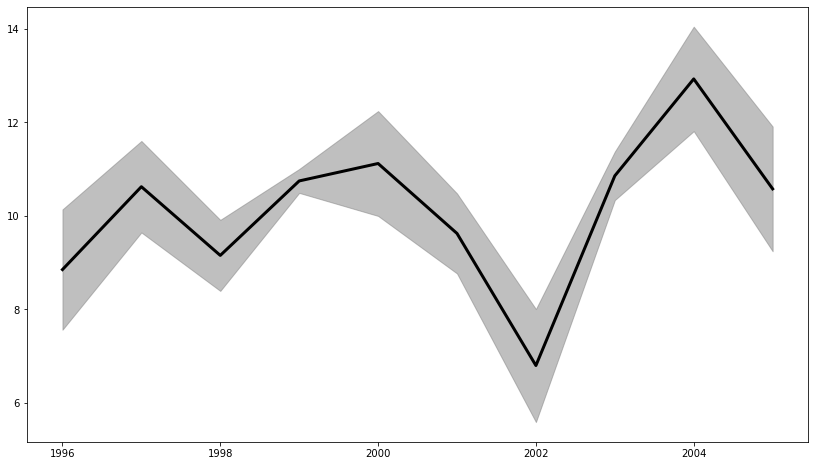

In [146]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF = dict_plot_data_obs_ax[site][co2_case]
Standard_error_DF = dict_plot_data_obs_ase[site][co2_case]
# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

# Create the figure and axis
#plt.figure(figsize=(10, 6))

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df = dict_plot_data_mod[site][co2_case][fn][min_checks]["NUP"]
years = df["Year"]
#df.set_index('Year', inplace=True)


for fn in fns:
    mean_model = dict_plot_data_mod[site][co2_case][fn][min_checks]["NUP"]["mean"]
    std_model  = dict_plot_data_mod[site][co2_case][fn][min_checks]["NUP"]["std"]
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NUP [{NUP_units}]', fontsize=18)
plt.title(f'NUP Models and Obs {site} - {co2_case} - {min_checks}\n', fontsize= 20)
plt.legend(fontsize=16, loc="upper right")
plt.ylim (3, 20) 
# Show grid and the plot
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NUP_Modex_{site}_{co2_case}_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()


## NPP response (final)

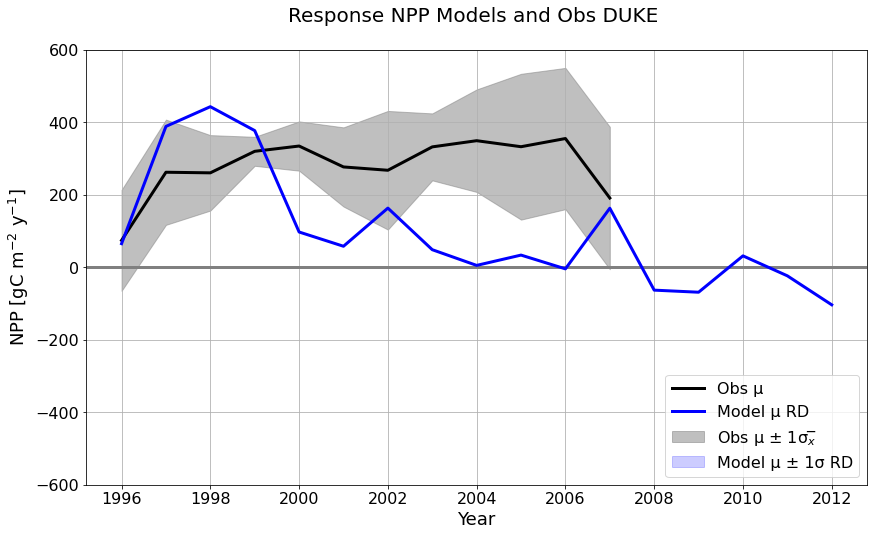

In [121]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NPP']
se_npp = Standard_error_DF['NPP']

plt.axhline(y=0, color='gray', linestyle='-', linewidth=3)

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["FATES_NPP_Minus_EXCESS_RESP"]

years = df0["Year"]
#df.set_index('Year', inplace=True)


# plot lines
#for column in list(df.columns)[:-1]:
#    plt.plot(years, df[column], linestyle='--', marker='o', label=column, color="brown", alpha=0.5)
    



for fn in fns:
    df1 = dict_plot_data_mod[site][CO2_cases[1]][fn]["FATES_NPP_Minus_EXCESS_RESP"]
    df0 = dict_plot_data_mod[site][CO2_cases[0]][fn]["FATES_NPP_Minus_EXCESS_RESP"]
    mean_model = df1["mean"] - df0["mean"]
    std_model  = (df1["std"]**2 + df0["std"]**2)**0.5
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f'NPP [{NPP_units}]', fontsize=18)
plt.title(f'Response NPP Models and Obs {site} \n', fontsize= 20)

plt.ylim (-600, 600) 
# Show grid and the plot
plt.grid(True)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Plot a horizontal line at y = 0
plt.legend(fontsize=16, loc="lower right")
# Display the plot
#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NPP_Modex_{site}_Response_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()


## NUP response (final)

NameError: name 'min_checks' is not defined

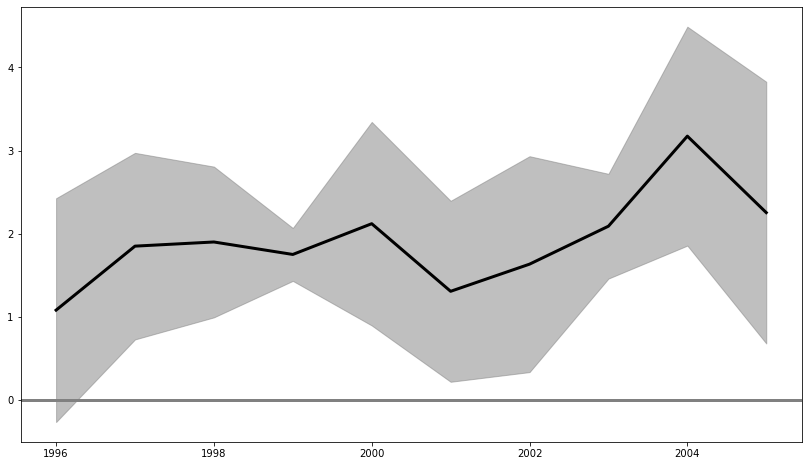

In [122]:
# Set the year as the index

# Plot the data
plt.figure(figsize=(14, 8))

# OBS

Mean_DF1 = dict_plot_data_obs_ax[site][CO2_cases[1]].reset_index(drop=True)
Mean_DF0 = dict_plot_data_obs_ax[site][CO2_cases[0]].reset_index(drop=True)

Mean_DF = Mean_DF1[["YEAR","NPP", "NUP"]] - Mean_DF0[["YEAR","NPP", "NUP"]]
Mean_DF["YEAR"] = Mean_DF1["YEAR"]

Standard_error_DF1 = dict_plot_data_obs_ase[site][CO2_cases[1]].reset_index(drop=True)
Standard_error_DF0 = dict_plot_data_obs_ase[site][CO2_cases[0]].reset_index(drop=True)

Standard_error_DF = ((Standard_error_DF1[["YEAR","NPP", "NUP"]])**2 + (Standard_error_DF0[["YEAR","NPP", "NUP"]])**2)**.5
Standard_error_DF["YEAR"] = Standard_error_DF1["YEAR"]

# Extracting the relevant columns
years = Mean_DF['YEAR']
mean_npp = Mean_DF['NUP']
se_npp = Standard_error_DF['NUP']

plt.axhline(y=0, color='gray', linestyle='-', linewidth=3)

# Plot NPP with shaded error bars
plt.plot(years, mean_npp, label='Obs μ', color='black', lw=3)
plt.fill_between(years, mean_npp - se_npp, mean_npp + se_npp, label=f'Obs μ ± 1σ$_x̅$' , color='gray', alpha=0.5)
#plt.fill_between(years, mean_npp - se_npp*1.96, mean_npp + se_npp*1.96, label=f'Obs μ ± 2σ$_x̅$', color='gray', alpha=0.3)

# MODEL

df0 = dict_plot_data_mod[site][CO2_cases[0]][fn][min_checks]["FATES_NPP_Minus_EXCESS_RESP"]

years = df0["Year"]

for fn in fns:
    df1 = dict_plot_data_mod[site][CO2_cases[1]][fn][min_checks]["NUP"]
    df0 = dict_plot_data_mod[site][CO2_cases[0]][fn][min_checks]["NUP"]
    mean_model = df1["mean"] - df0["mean"]
    std_model  = (df1["std"]**2 + df0["std"]**2)**0.5
    if fn == "RD": color_fn = "blue"
    if fn == "ECA" : color_fn = "green"
    plt.plot(years, mean_model, label=f'Model μ {fn}', color=color_fn, lw=3)
    plt.fill_between(years, mean_model - std_model, mean_model + std_model, label=f'Model μ ± 1σ {fn}', color=color_fn, alpha=0.2)
    #plt.fill_between(years, mean_model - std_model*2, mean_model + std_model*2, label=f'Model μ ± 2σ {fn}', color=color_fn, alpha=0.2)
    

# Add labels and title
plt.xlabel('Year',fontsize=18 )
plt.ylabel(f' NUP [{NUP_units}]', fontsize=18)
plt.title(f'Response NUP Models and Obs {site} \n', fontsize= 20)
plt.legend(fontsize=16, loc="lower right")
plt.ylim (-10, 10) 
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
# Show grid and the plot
plt.grid(True)
# Display the plot

#plt.savefig(f"/Users/ud4/repos/GitHub/FATESFACE/Plume_Plots/Final/NUP_Modex_{site}_Response_Checks_{min_checks}.png",bbox_inches='tight')
plt.show()
